In [1]:
import pandas as pd
from io import StringIO
import requests

In [2]:
data = requests.get('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day48-simple-linear-regression/placement.csv').text
df = pd.read_csv(StringIO(data))
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


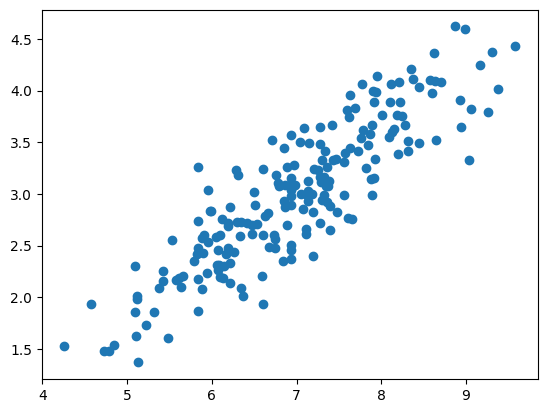

In [3]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'], df['package'])

In [4]:
df.iloc[:,0]

0      6.89
1      5.12
2      7.82
3      7.42
4      6.94
       ... 
195    6.93
196    5.89
197    7.21
198    7.63
199    6.22
Name: cgpa, Length: 200, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:, [0]], df.iloc[: ,[-1]], test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred = lr.predict(x_test)

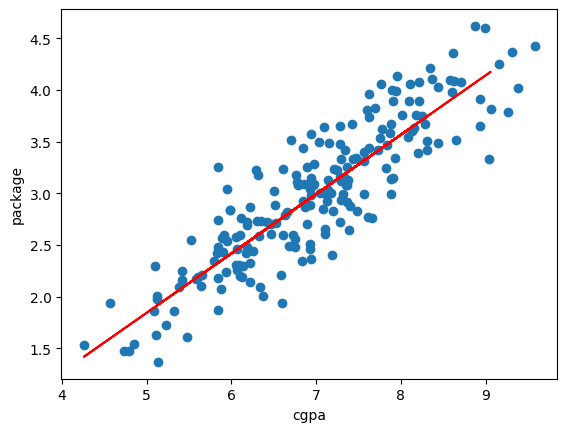

In [8]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')
plt.plot(x_test, y_pred, color = 'red')

In [9]:
lr.coef_

array([[0.57425647]])

In [10]:
lr.intercept_

array([-1.02700694])

In [11]:
lr.predict([[6.89]])

/workspaces/ml_practicals/mlvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[2.92962016]])

In [12]:
lr.coef_*6.89+lr.intercept_

array([[2.92962016]])

In [13]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_squared_error

In [17]:
mean_absolute_error(y_pred=y_pred, y_true=y_test)

0.23150985393278373

In [19]:
mean_squared_error(y_pred, y_test)

0.08417638361329656

In [20]:
root_mean_squared_error(y_pred, y_test)

0.2901316659954521

In [21]:
r2_score(y_pred, y_test)

0.733797338294438